# NYC Taxi Trip Duration — v2 Tuned Model

- Caleb Solomons
- Mubeen Yaqub
- Mai Lam
- Anh Minh Tran

**DSCI 592 Capstone — Team GridRunners**
**Target:** `trip_duration_min` (regression — minutes)


1. **Target** — `trip_duration_min` instead of `fare_amount`.
2. **Bounds** — tightened to `1–120 min` (cleaning notebook already filtered to 1–300; trim further because legit yellow-taxi trips rarely exceed 2 hours and the long tail is mostly airport-queue artifacts and data errors that hurt the fit on the meter-driven).
3. **Deck artifacts** — pred-vs-actual in minutes, residuals in minutes, no fare-bin slicing.

Output: `xgb_v2_duration.json` — loaded directly by `gridrunners_demo.py` via `predict_duration`.

## 1. Setup

In [ ]:
!pip -q install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.5 MB/s eta 0:00:00


In [ ]:
import json
import math
import warnings
from datetime import date
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
sns.set_style("whitegrid")

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | optuna {optuna.__version__}")

pandas 2.2.2 | numpy 2.0.2 | xgboost 3.2.0 | optuna 4.8.0


## 2. Config Tuning


In [ ]:
SAMPLE_SIZE = 1_500_000
TUNING_SAMPLE = 250_000
USE_FULL_DATASET = False

N_TRIALS = 30
CV_FOLDS = 5

DUR_MIN, DUR_MAX = 1.0, 120.0
DIST_MIN, DIST_MAX = 0.3, 50.0
SPEED_MIN, SPEED_MAX = 0.5, 80.0

ENABLE_WEATHER_JOIN = True
ENABLE_EVENT_FLAGS  = True
ENABLE_DISTANCE_PROXIES = True

XGB_DEVICE = "cuda"

## 3. Mount Drive & Set Paths

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# >>> EDIT <<<

DRIVE_BASE = Path("/content/drive/MyDrive/DSCI 592")
DATA_PATH = Path("/content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet")

OUTPUT_DIR = DRIVE_BASE / "v2_tuned_duration"
FIGURE_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"

for d in (OUTPUT_DIR, FIGURE_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Reading data from : {DATA_PATH}")
print(f"Saving outputs to : {OUTPUT_DIR}")

Mounted at /content/drive
Reading data from : /content/drive/MyDrive/DSCI 592/2023_Yellow_Taxi_Cleaned.parquet
Saving outputs to : /content/drive/MyDrive/DSCI 592/v2_tuned_duration


## 4. Load Data & Inspect Columns

In [ ]:
df_full = pd.read_parquet(DATA_PATH)

print(f"Full dataset shape : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"Memory footprint : {df_full.memory_usage(deep=True).sum() / 1e9:.2f} GB\n")
print("Columns and dtypes:")

print(df_full.dtypes.to_string())

Full dataset shape : 37,017,621 rows × 35 cols
Memory footprint   : 29.12 GB

Columns and dtypes:
VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
trip_duration_min               float64
speed_mph                       float64
pickup_hour                       int32
pickup_dow            

## 5. Column Mapping & Leakage Discipline

- `trip_distance` (would be a routing-API estimate in production)
- `passenger_count`
- Pickup-time features: hour, day-of-week, weekend
- Pickup & dropoff borough
- `VendorID`, `RatecodeID`
- `temp_f`, `precip_in`, `is_rainy` (weather)
- `is_us_holiday`, `is_nyc_event` (event-day flags)
- `haversine_mi`, `manhattan_mi` (geometric distance proxies)

**Target swap:** `trip_duration_min` instead of `fare_amount`. Both are continuous regression targets, so the only structural change downstream is the  bounds and the deck-artifact units.

**Leakage note:** `trip_distance` is what a routing API would give at request time. *not* using `tpep_dropoff_datetime` or `total_amount` (post-trip).

In [ ]:
COL = {
    "target":         "trip_duration_min",   # <<< swapped from fare_amount
    "trip_distance":  "trip_distance",
    "passengers":     "passenger_count",
    "hour":           "pickup_hour",
    "dow":            "pickup_dow",
    "weekend":        "is_weekend",
    "pu_borough":     "PU_borough",
    "do_borough":     "DO_borough",
    "vendor":         "VendorID",
    "pickup_dt":      "tpep_pickup_datetime",
    "ratecode":       "RatecodeID",
}


NUMERIC_BASE = [COL["trip_distance"], COL["passengers"]]
CATEGORICAL_BASE = [COL["hour"], COL["dow"], COL["weekend"],
                    COL["pu_borough"], COL["do_borough"], COL["vendor"],
                    COL["ratecode"]]
TARGET = COL["target"]

ENG_NUMERIC = []
ENG_CATEGORICAL = []

needed = set(NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]])
missing = sorted(needed - set(df_full.columns))

if missing:
    raise KeyError(f"Missing columns — fix COL mapping: {missing}")

print("All expected columns present. Proceeding.")

All expected columns present. Proceeding.


## 6. Filter

Bounds are duration-specific (`1–120 min`). Rationale:
- **Lower bound (1 min)**
- **Upper bound (120 min)**

Distance bound matches v2 fare so training distribution is consistent across the two regression models — important because the Streamlit demo runs both predictions on the same feature row, and don't want them disagreeing on which trips are in-distribution.

In [ ]:
mask = (
    df_full[TARGET].between(DUR_MIN, DUR_MAX)
    & df_full[COL["trip_distance"]].between(DIST_MIN, DIST_MAX)
    & df_full[COL["ratecode"]].notna()
    & df_full[NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].notna().all(axis=1)
)

df_clean = df_full.loc[mask, NUMERIC_BASE + CATEGORICAL_BASE + [TARGET, COL["pickup_dt"]]].copy()
df_clean[COL["ratecode"]] = df_clean[COL["ratecode"]].astype("int8")

dropped = (~mask).sum()

print(f"Rows dropped by tightened filter : {dropped:,} ({dropped / len(df_full):.2%})")
print(f"Rows remaining                   : {len(df_clean):,}")
print(f"\nDuration distribution (post-filter):")
print(df_clean[TARGET].describe().round(2).to_string())

Rows dropped by tightened filter : 1,930,998 (5.22%)
Rows remaining                   : 35,086,623

Duration distribution (post-filter):
count    35086623.00
mean           16.40
std            12.91
min             1.02
25%             7.82
50%            12.70
75%            20.60
max           120.00


## 7. Feature Engineering — Pillar 1: Event-Day Flags

Flags are derived from the pickup date.

- **`is_us_holiday`** — federal holidays via `USFederalHolidayCalendar`. Duration distributions shift on holidays: lighter Manhattan traffic → faster trips, but heavier airport queues → slower airport runs.
- **`is_nyc_event`** — hand-curated NYC event days for 2023.

In [ ]:
from pandas.tseries.holiday import USFederalHolidayCalendar

holidays_2023 = pd.DatetimeIndex(
    USFederalHolidayCalendar().holidays(start="2023-01-01", end="2023-12-31")
).normalize()

NYC_EVENTS_2023 = pd.to_datetime([
    "2023-06-25",  # NYC Pride March
    "2023-09-10",  # US Open men's final
    "2023-11-05",  # NYC Marathon
    "2023-11-23",  # Macy's Thanksgiving Day Parade
    "2023-12-31",  # NYE Times Square
]).normalize()

if ENABLE_EVENT_FLAGS:

    pickup_date = df_clean[COL["pickup_dt"]].dt.normalize()

    df_clean["is_us_holiday"] = pickup_date.isin(holidays_2023).astype("int8")
    df_clean["is_nyc_event"]  = pickup_date.isin(NYC_EVENTS_2023).astype("int8")

    ENG_CATEGORICAL += ["is_us_holiday", "is_nyc_event"]

    print(f"US holiday trips : {df_clean['is_us_holiday'].sum():,} "
          f"({df_clean['is_us_holiday'].mean():.2%})")
    
    print(f"NYC event trips  : {df_clean['is_nyc_event'].sum():,} "
          f"({df_clean['is_nyc_event'].mean():.2%})")
else:
    print("Event-day flags disabled via ENABLE_EVENT_FLAGS=False")

US holiday trips : 765,430 (2.18%)
NYC event trips  : 397,251 (1.13%)


## 8. Feature Engineering — Pillar 2: Distance Proxies

`trip_distance` is the recorded meter distance (post-trip); the geometric proxies approximate what a routing API would estimate at request time.

- **Haversine**
$$ d_{hav} = 2R \cdot \arcsin\!\sqrt{\sin^2\!\tfrac{\Delta\varphi}{2} + \cos\varphi_1\cos\varphi_2\sin^2\!\tfrac{\Delta\lambda}{2}} $$
where $R$ is Earth's radius (3958.8 mi), $\varphi$ is latitude in radians, $\lambda$ is longitude in radians.

- **Manhattan-L1** — taxicab distance. At NYC latitude (~40.7°N), 1° latitude ≈ 69 mi and 1° longitude ≈ 52.5 mi.

In [ ]:
BOROUGH_CENTROIDS = {
    "Manhattan":     (40.7831, -73.9712),
    "Brooklyn":      (40.6782, -73.9442),
    "Queens":        (40.7282, -73.7949),
    "Bronx":         (40.8448, -73.8648),
    "Staten Island": (40.5795, -74.1502),
    "EWR":           (40.6895, -74.1745),
}

EARTH_R_MI = 3958.8

def _haversine_vec(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    return 2 * EARTH_R_MI * np.arcsin(np.sqrt(a))

if ENABLE_DISTANCE_PROXIES:

    pu = df_clean[COL["pu_borough"]].astype(str)
    do = df_clean[COL["do_borough"]].astype(str)

    pu_lat = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    pu_lon = pu.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)
    do_lat = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[0]).to_numpy(dtype=float)
    do_lon = do.map(lambda b: BOROUGH_CENTROIDS.get(b, (np.nan, np.nan))[1]).to_numpy(dtype=float)

    df_clean["haversine_mi"] = _haversine_vec(pu_lat, pu_lon, do_lat, do_lon)
    df_clean["manhattan_mi"] = (np.abs(pu_lat - do_lat) * 69.0 + np.abs(pu_lon - do_lon) * 52.5)

    
    fb = df_clean[COL["trip_distance"]].to_numpy()

    df_clean["haversine_mi"] = np.where(np.isnan(df_clean["haversine_mi"]), fb, df_clean["haversine_mi"])
    df_clean["manhattan_mi"] = np.where(np.isnan(df_clean["manhattan_mi"]), fb, df_clean["manhattan_mi"])

    ENG_NUMERIC += ["haversine_mi", "manhattan_mi"]

    print(f"haversine_mi  — mean {df_clean['haversine_mi'].mean():.2f} mi, max {df_clean['haversine_mi'].max():.2f} mi")
    print(f"manhattan_mi  — mean {df_clean['manhattan_mi'].mean():.2f} mi, max {df_clean['manhattan_mi'].max():.2f} mi")
    
else:
    print("Distance proxies disabled via ENABLE_DISTANCE_PROXIES=False")

haversine_mi  — mean 1.32 mi, max 49.86 mi
manhattan_mi  — mean 1.69 mi, max 49.86 mi


## 9. Feature Engineering — Pillar 3: Weather Join

Daily Central Park weather joined by `pickup_date`.

For duration weather has a stronger expected effect than it does on fare: rain slows surface traffic, congesting Manhattan grid trips disproportionately. Expect `is_rainy` to land higher in feature importance for duration than it did for fare.

In [ ]:
def _synthetic_nyc_weather(year: int = 2023) -> pd.DataFrame:

    days = pd.date_range(f"{year}-01-01", f"{year}-12-31", freq="D")
    monthly_temp = [32, 35, 43, 53, 63, 72, 78, 76, 69, 58, 47, 37]

    rng = np.random.default_rng(SEED)

    temps   = np.array([monthly_temp[d.month - 1] + rng.normal(0, 4) for d in days])

    precip  = rng.exponential(0.12, size=len(days))
    precip[rng.random(len(days)) < 0.55] = 0.0

    return pd.DataFrame({"date": days.normalize(), "temp_f": temps, "precip_in": precip})

def _fetch_open_meteo(year: int = 2023) -> pd.DataFrame:

    import requests

    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude=40.7831&longitude=-73.9712"
        f"&start_date={year}-01-01&end_date={year}-12-31"
        f"&daily=temperature_2m_mean,precipitation_sum"
        f"&temperature_unit=fahrenheit&precipitation_unit=inch&timezone=America/New_York"
    )

    r = requests.get(url, timeout=20)
    r.raise_for_status()

    j = r.json()["daily"]

    return pd.DataFrame({
        "date":      pd.to_datetime(j["time"]).normalize(),
        "temp_f":    j["temperature_2m_mean"],
        "precip_in": j["precipitation_sum"],
    })

if ENABLE_WEATHER_JOIN:

    try:

        weather = _fetch_open_meteo(2023)
        source = "Open-Meteo (real)"

    except Exception as e:

        print(f"  Open-Meteo unreachable ({type(e).__name__}); using synthetic climatology.")

        weather = _synthetic_nyc_weather(2023)
        source = "synthetic (fallback)"

    weather["is_rainy"] = (weather["precip_in"] > 0.1).astype("int8")
    df_clean["_pickup_date"] = df_clean[COL["pickup_dt"]].dt.normalize()
    df_clean = df_clean.merge(weather, left_on="_pickup_date", right_on="date", how="left")
    df_clean = df_clean.drop(columns=["_pickup_date", "date"])

    ENG_NUMERIC += ["temp_f", "precip_in"]
    ENG_CATEGORICAL += ["is_rainy"]

    print(f"Weather source : {source}")
    print(f"Days joined    : {weather['date'].nunique()} / 365")
    
else:
    print("Weather join disabled via ENABLE_WEATHER_JOIN=False")

Weather source : Open-Meteo (real)
Days joined    : 365 / 365


## 10. Feature Set + Native Categorical Conversion

Final feature schema. Must match `ALL_FEATURES` in `gridrunners_demo.py` exactly — same columns, same order, same dtypes — or `xgb.Booster.predict` errors out at inference time with a feature mismatch.

In [ ]:
NUMERIC_FEATURES     = NUMERIC_BASE + ENG_NUMERIC
CATEGORICAL_FEATURES = CATEGORICAL_BASE + ENG_CATEGORICAL
ALL_FEATURES         = NUMERIC_FEATURES + CATEGORICAL_FEATURES

for c in CATEGORICAL_FEATURES:
    df_clean[c] = df_clean[c].astype("category")

print(f"Numeric features      ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features  ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}")
print(f"Total feature count   : {len(ALL_FEATURES)}")


EXPECTED = [
    "trip_distance", "passenger_count", "haversine_mi", "manhattan_mi",
    "temp_f", "precip_in", "pickup_hour", "pickup_dow", "is_weekend",
    "PU_borough", "DO_borough", "VendorID", "RatecodeID",
    "is_us_holiday", "is_nyc_event", "is_rainy",
]

assert ALL_FEATURES == EXPECTED, (
    f"FEATURE SCHEMA DRIFT — Streamlit will fail at predict time.\n"
    f"  got      : {ALL_FEATURES}\n"
    f"  expected : {EXPECTED}"
)

print("\n✓ Feature schema matches gridrunners_demo.py ALL_FEATURES")

Numeric features      (6): ['trip_distance', 'passenger_count', 'haversine_mi', 'manhattan_mi', 'temp_f', 'precip_in']
Categorical features  (10): ['pickup_hour', 'pickup_dow', 'is_weekend', 'PU_borough', 'DO_borough', 'VendorID', 'RatecodeID', 'is_us_holiday', 'is_nyc_event', 'is_rainy']
Total feature count   : 16

✓ Feature schema matches gridrunners_demo.py ALL_FEATURES


## 11. Stratified Samples — Tuning + Evaluation

Stratified on `pickup_hour × PU_borough` to preserve temporal-spatial balance.

- **`tune_sample`** (250K) — Optuna trials. Smaller = more trials per minute.
- **`eval_sample`** (1.5M) — K-fold CV runs for generalization estimate.

In [ ]:
df_clean["_strat"] = (
    df_clean[COL["hour"]].astype(str) + "|" + df_clean[COL["pu_borough"]].astype(str)
)

def _stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:

    frac = min(1.0, n / len(df))
    out = df.groupby("_strat").sample(frac=frac, random_state=seed)
    
    return out.drop(columns=["_strat"]).reset_index(drop=True)

eval_sample = _stratified_sample(df_clean, SAMPLE_SIZE,   seed=SEED)
tune_sample = _stratified_sample(df_clean, TUNING_SAMPLE, seed=SEED + 1)

print(f"Evaluation sample : {len(eval_sample):,} rows")
print(f"Tuning sample     : {len(tune_sample):,} rows")

Evaluation sample : 1,499,995 rows
Tuning sample     : 249,994 rows


## 12. Hyperparameter Sweep — Optuna over XGBoost

TPE sampler, RMSE objective. XGBoost on tabular regression with 1.5M rows tends to converge on `max_depth ≈ 8–10`, `learning_rate ≈ 0.05–0.1`, `n_estimators ≈ 500–1000`.

In [ ]:
def objective(trial: optuna.Trial) -> float:

    params = {
        "objective":          "reg:squarederror",
        "eval_metric":        "rmse",
        "tree_method":        "hist",
        "device":             XGB_DEVICE,
        "enable_categorical": True,
        "random_state":       SEED,
        "verbosity":          0,

        "max_depth":        trial.suggest_int("max_depth", 4, 12),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1500),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
    }

    X = tune_sample[ALL_FEATURES]
    y = tune_sample[TARGET]

    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=SEED)

    model = xgb.XGBRegressor(**params, early_stopping_rounds=50, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    preds = model.predict(X_va)
    return float(np.sqrt(mean_squared_error(y_va, preds)))


study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    study_name="duration_v2_tuning",
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\n" + "=" * 60)
print(f" OPTUNA — best RMSE: {study.best_value:.4f} min  (after {N_TRIALS} trials)")
print("=" * 60)

for k, v in study.best_params.items():
    print(f"  {k:<20} {v}")

with open(METRICS_DIR / "optuna_best_params.json", "w") as f:
    
    json.dump({"best_rmse": study.best_value, "best_params": study.best_params,
               "n_trials": N_TRIALS, "tuning_sample_size": len(tune_sample)}, f, indent=2)

  0%|          | 0/30 [00:00<?, ?it/s]


 OPTUNA — best RMSE: 5.4376 min  (after 30 trials)
  max_depth            9
  learning_rate        0.013712638307629062
  n_estimators         1189
  min_child_weight     16
  subsample            0.8660698517703787
  colsample_bytree     0.8328972689415064
  reg_alpha            3.020888692446116
  reg_lambda           0.5041875573756835
  gamma                3.653085503216601


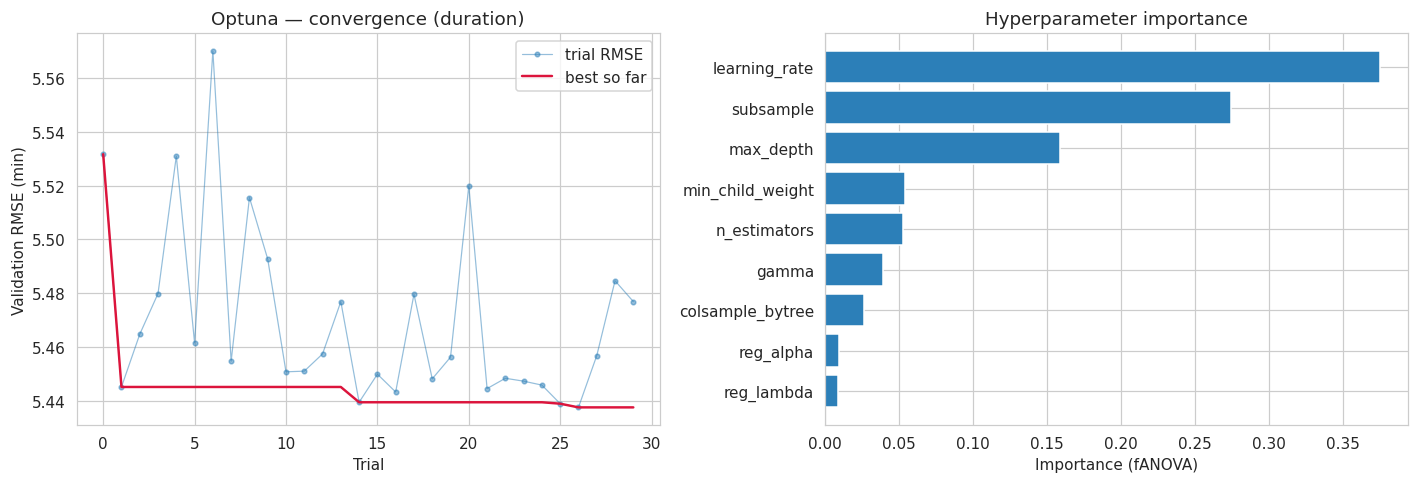

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

trials_df = study.trials_dataframe()

axes[0].plot(trials_df["number"], trials_df["value"], marker="o", markersize=3,
             linewidth=0.8, color="#2c7fb8", alpha=0.5, label="trial RMSE")

axes[0].plot(trials_df["number"], trials_df["value"].cummin(),
             color="crimson", linewidth=1.6, label="best so far")

axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Validation RMSE (min)")
axes[0].set_title("Optuna — convergence (duration)")
axes[0].legend(loc="upper right")

try:

    importances = optuna.importance.get_param_importances(study)
    imp_df = pd.Series(importances).sort_values()

    axes[1].barh(imp_df.index, imp_df.values, color="#2c7fb8")
    axes[1].set_xlabel("Importance (fANOVA)")
    axes[1].set_title("Hyperparameter importance")

except Exception as e:

    axes[1].text(0.5, 0.5, f"importance unavailable\n({type(e).__name__})",
                 ha="center", va="center", transform=axes[1].transAxes)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "optuna_search.png")

plt.show()

## 13. K-Fold Cross-Validation with Best Params

Evaluate the winning Optuna config honestly on the full 1.5M `eval_sample` using `CV_FOLDS`-fold CV. Reported metric becomes mean ± std across folds.

In [ ]:
final_params = {
    **study.best_params,
    "objective":          "reg:squarederror",
    "eval_metric":        "rmse",
    "tree_method":        "hist",
    "device":             XGB_DEVICE,
    "enable_categorical": True,
    "random_state":       SEED,
    "verbosity":          0,
}

X_all = eval_sample[ALL_FEATURES]
y_all = eval_sample[TARGET]

kfold = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_metrics = []

for fold_i, (tr_idx, va_idx) in enumerate(kfold.split(X_all), start=1):

    X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
    y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

    model = xgb.XGBRegressor(**final_params, n_jobs=-1)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    preds = model.predict(X_va)

    rmse = float(np.sqrt(mean_squared_error(y_va, preds)))
    mae = float(mean_absolute_error(y_va, preds))
    r2 = float(r2_score(y_va, preds))
    
    fold_metrics.append({"fold": fold_i, "rmse": rmse, "mae": mae, "r2": r2})

    print(f"  Fold {fold_i}/{CV_FOLDS} — RMSE {rmse:.3f} min | MAE {mae:.3f} min | R² {r2:.4f}")

cv_df = pd.DataFrame(fold_metrics)
cv_summary = cv_df.agg(["mean", "std"]).round(4)

print("\n" + "=" * 60)
print(f" {CV_FOLDS}-FOLD CV SUMMARY")
print("=" * 60)
print(f"  RMSE : {cv_summary.loc['mean', 'rmse']:.3f} ± {cv_summary.loc['std', 'rmse']:.3f} min")
print(f"  MAE  : {cv_summary.loc['mean', 'mae']:.3f} ± {cv_summary.loc['std', 'mae']:.3f} min")
print(f"  R²   : {cv_summary.loc['mean', 'r2']:.4f} ± {cv_summary.loc['std', 'r2']:.4f}")

cv_df.to_csv(METRICS_DIR / "kfold_cv_metrics.csv", index=False)

  Fold 1/5 — RMSE 5.412 min | MAE 3.603 min | R² 0.8231
  Fold 2/5 — RMSE 5.415 min | MAE 3.611 min | R² 0.8239
  Fold 3/5 — RMSE 5.398 min | MAE 3.601 min | R² 0.8251
  Fold 4/5 — RMSE 5.416 min | MAE 3.607 min | R² 0.8239
  Fold 5/5 — RMSE 5.430 min | MAE 3.602 min | R² 0.8222

 5-FOLD CV SUMMARY
  RMSE : 5.414 ± 0.011 min
  MAE  : 3.605 ± 0.004 min
  R²   : 0.8236 ± 0.0011


## 14. Final Model — Held-Out 20% + Save

Train model on 80/20 split and **save it as `xgb_v2_duration.json`** — the exact filename `gridrunners_demo.py` expects.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED)

model_final = xgb.XGBRegressor(**final_params, n_jobs=-1)
model_final.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred = model_final.predict(X_test)

rmse_v2 = float(np.sqrt(mean_squared_error(y_test, y_pred)))
mae_v2 = float(mean_absolute_error(y_test, y_pred))
r2_v2 = float(r2_score(y_test, y_pred))

print(f"v2 tuned duration (held-out 20%) — RMSE: {rmse_v2:.3f} min | MAE: {mae_v2:.3f} min | R²: {r2_v2:.4f}")

# ── Save in the format gridrunners_demo.py loads ─────────────────────────────

# Streamlit does: booster = xgb.Booster(); booster.load_model(str(path))
# Save underlying booster of XGBRegressor via get_booster().save_model.

model_path = OUTPUT_DIR / "xgb_v2_duration.json"
model_final.get_booster().save_model(str(model_path))

print(f"\n✓ Model saved to : {model_path}")
print(f"  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.")

v2 tuned duration (held-out 20%) — RMSE: 5.410 min | MAE: 3.602 min | R²: 0.8232

✓ Model saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_duration/xgb_v2_duration.json
  Copy this file into ./models/ alongside xgb_v2_fare.json for the demo to load it.


## 15. Check — Round-Trip Load + Predict

Re-load the saved booster the same way the Streamlit app does, run a prediction on a single test row, and verify the output matches the in-memory model. This catches silent serialization issues (categorical encoding drift, feature-name reordering) *before* the demo is in front of an audience.

In [ ]:
booster_reloaded = xgb.Booster()
booster_reloaded.load_model(str(model_path))

# Build a DMatrix exactly the way the Streamlit app does

one_row = X_test.iloc[[0]]
dmat = xgb.DMatrix(one_row, enable_categorical=True)

pred_from_disk = float(booster_reloaded.predict(dmat)[0])
pred_in_memory = float(model_final.predict(one_row)[0])

print(f"Prediction from in-memory model : {pred_in_memory:.3f} min")
print(f"Prediction from reloaded booster: {pred_from_disk:.3f} min")
print(f"Difference                       : {abs(pred_in_memory - pred_from_disk):.6f} min")

assert abs(pred_in_memory - pred_from_disk) < 1e-4, "Serialization round-trip mismatch!"
print("\n✓ Round-trip passed — Streamlit will see the same predictions this notebook does.")

Prediction from in-memory model : 17.230 min
Prediction from reloaded booster: 17.230 min
Difference                       : 0.000002 min

✓ Round-trip passed — Streamlit will see the same predictions this notebook does.


## 16. Predicted vs Actual

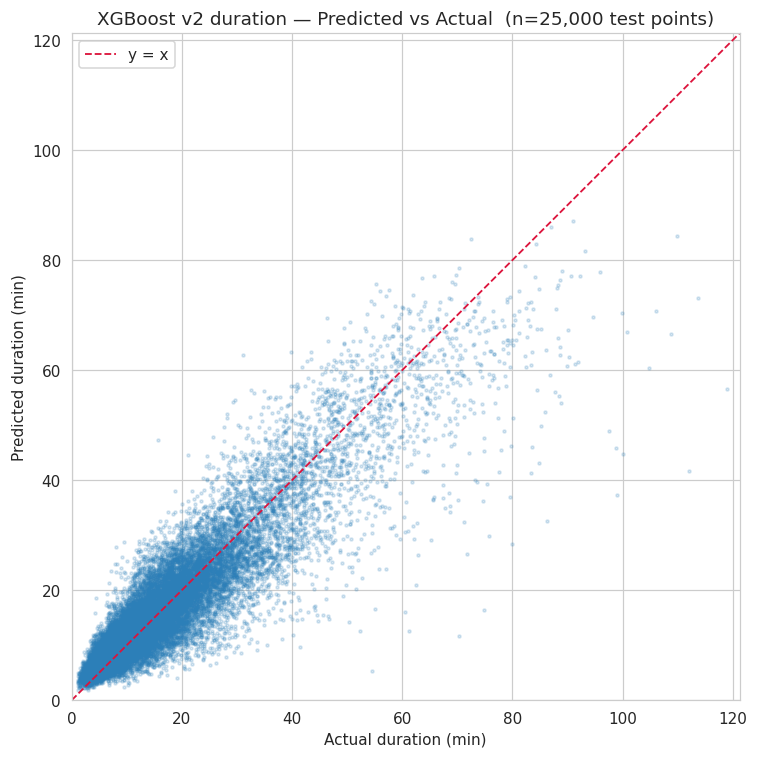

In [ ]:
plot_n = 25_000

idx = np.random.RandomState(SEED).choice(len(y_test), size=min(plot_n, len(y_test)), replace=False)

y_t = np.asarray(y_test)[idx]
y_p = y_pred[idx]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_t, y_p, s=4, alpha=0.18, color="#2c7fb8")

lim_max = max(y_t.max(), y_p.max()) * 1.02

ax.plot([0, lim_max], [0, lim_max], color="crimson", linestyle="--", linewidth=1.2, label="y = x")
ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_xlabel("Actual duration (min)")
ax.set_ylabel("Predicted duration (min)")
ax.set_title(f"XGBoost v2 duration — Predicted vs Actual  (n={len(idx):,} test points)")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_pred_vs_actual.png")

plt.show()

## 17. Residuals

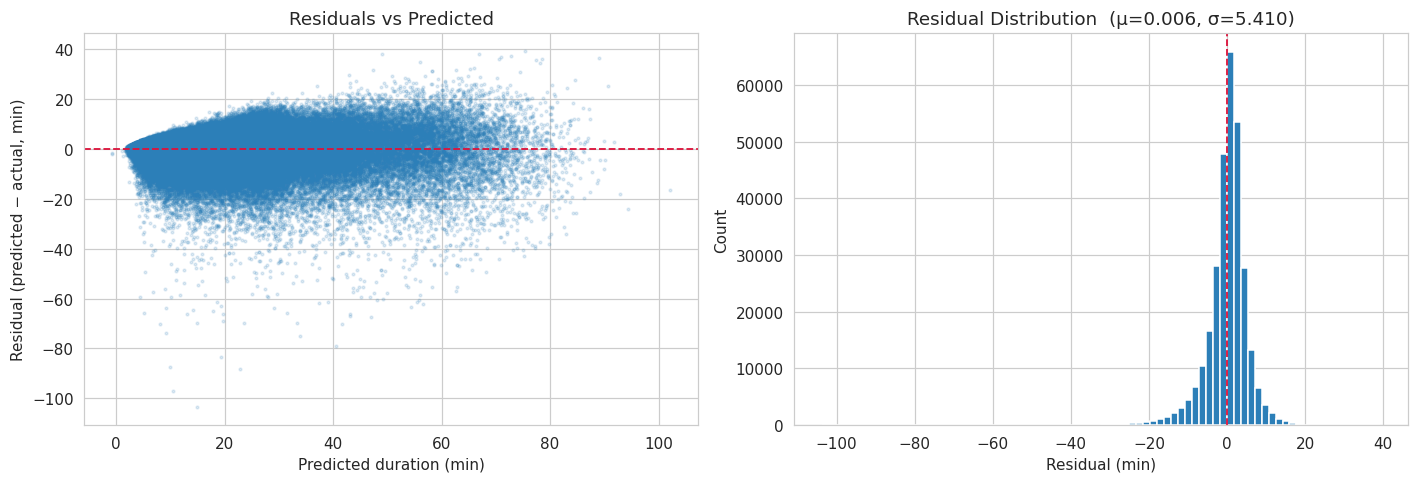

In [19]:
resid = y_pred - np.asarray(y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(y_pred, resid, s=3, alpha=0.15, color="#2c7fb8")
axes[0].axhline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted duration (min)")
axes[0].set_ylabel("Residual (predicted − actual, min)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(resid, bins=80, color="#2c7fb8", edgecolor="white")
axes[1].axvline(0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual (min)")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution  (μ={resid.mean():.3f}, σ={resid.std():.3f})")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_residuals.png")
plt.show()

## 18. Feature Importance

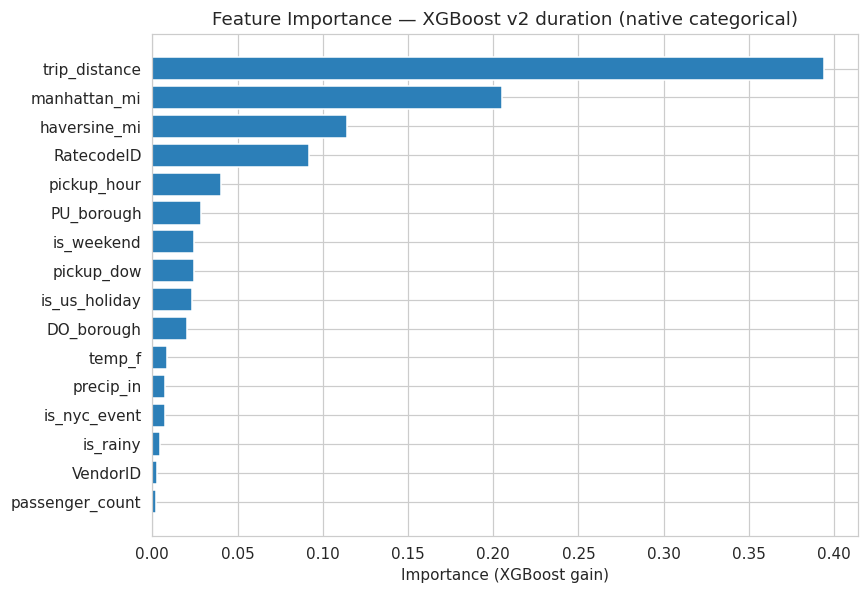

,feature,importance
15,trip_distance,0.3943
14,manhattan_mi,0.2049
13,haversine_mi,0.1143
12,RatecodeID,0.0917
11,pickup_hour,0.0401
10,PU_borough,0.0288
9,is_weekend,0.0246
8,pickup_dow,0.0245
7,is_us_holiday,0.0233
6,DO_borough,0.0206


In [ ]:
imp_df = (pd.DataFrame({
    "feature": model_final.feature_names_in_,
    "importance": model_final.feature_importances_,
}).sort_values("importance", ascending=True).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(imp_df["feature"], imp_df["importance"], color="#2c7fb8")
ax.set_xlabel("Importance (XGBoost gain)")
ax.set_title("Feature Importance — XGBoost v2 duration (native categorical)")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_feature_importance.png")

plt.show()

imp_df.sort_values("importance", ascending=False).round(4)

## 19. Residual Investigation

1. **Worst-50 by |residual|.** Scan for patterns.
2. **Residual slices.** Mean and 95th-percentile absolute residual binned by duration, distance, hour, and borough pair. Hot bins are tighter-bound candidates.


In [ ]:
abs_resid = np.abs(resid)
worst_idx = np.argsort(abs_resid)[-50:][::-1]

worst = X_test.iloc[worst_idx].copy()

worst.insert(0, "predicted_duration_min", np.round(y_pred[worst_idx], 2))
worst.insert(0, "actual_duration_min", np.round(np.asarray(y_test)[worst_idx], 2))
worst.insert(0, "residual_min", np.round(resid[worst_idx], 2))

worst = worst.reset_index(drop=True)
worst.to_csv(METRICS_DIR / "v2_worst_residuals.csv", index=False)

print("Top 50 worst misses — saved to v2_worst_residuals.csv")
print(f"Range of |residual| in worst-50 : {abs_resid[worst_idx].min():.2f} – {abs_resid[worst_idx].max():.2f} min")

worst.head(15)

Top 50 worst misses — saved to v2_worst_residuals.csv
Range of |residual| in worst-50 : 57.41 – 103.62 min


,residual_min,actual_duration_min,predicted_duration_min,trip_distance,passenger_count,haversine_mi,manhattan_mi,temp_f,precip_in,pickup_hour,pickup_dow,is_weekend,PU_borough,DO_borough,VendorID,RatecodeID,is_us_holiday,is_nyc_event,is_rainy
0,-103.62,118.57,14.940000,1.75,3.0,0.000000,0.00000,70.9,0.756,17,5,1,Manhattan,Manhattan,2,1,0,0,1
1,-96.93,107.37,10.430000,1.73,1.0,0.000000,0.00000,33.4,0.000,19,2,0,Manhattan,Manhattan,2,1,0,0,0
2,-88.11,111.02,22.900000,8.17,1.0,0.000000,0.00000,73.3,0.035,1,4,0,Manhattan,Manhattan,2,1,0,0,0
3,-87.60,97.60,10.000000,1.63,1.0,9.976598,13.04385,76.4,0.291,17,5,1,Manhattan,Queens,2,1,0,0,1
4,-83.42,102.78,19.360001,1.87,2.0,1.870000,1.87000,80.0,0.008,16,3,0,Manhattan,Unknown,2,1,0,0,0
5,-79.15,119.63,40.490002,19.88,1.0,19.880000,19.88000,45.5,0.000,5,2,0,Queens,Unknown,2,1,0,0,0
6,-75.05,108.95,33.900002,12.80,1.0,8.549432,11.28825,71.6,0.575,5,3,0,Brooklyn,Queens,1,99,0,0,1
7,-73.76,82.92,9.160000,2.22,1.0,9.976598,13.04385,66.1,0.000,2,6,1,Manhattan,Queens,2,1,0,0,0
8,-70.33,112.07,41.740002,19.04,1.0,9.976598,13.04385,40.5,0.000,19,1,0,Queens,Manhattan,2,2,0,0,0
9,-70.19,78.38,8.200000,0.87,1.0,0.870000,0.87000,73.6,0.894,17,6,1,Manhattan,Unknown,2,1,0,0,1


In [ ]:
diag = pd.DataFrame({
    "actual":   np.asarray(y_test),
    "pred":     y_pred,
    "abs_res":  abs_resid,
    "trip_distance": X_test[COL["trip_distance"]].to_numpy(),
    "hour":     X_test[COL["hour"]].astype(int).to_numpy(),
    "pu":       X_test[COL["pu_borough"]].astype(str).to_numpy(),
    "do":       X_test[COL["do_borough"]].astype(str).to_numpy(),
})

# duration (minutes)
diag["dur_bin"] = pd.cut(diag["actual"],
                          bins=[0, 5, 10, 20, 40, 60, DUR_MAX + 1],
                          labels=["≤5", "5–10", "10–20", "20–40", "40–60", ">60"])
# distance (miles)
diag["dist_bin"] = pd.cut(diag["trip_distance"],
                          bins=[0, 1, 3, 7, 15, DIST_MAX + 1],
                          labels=["≤1", "1–3", "3–7", "7–15", ">15"])

def _slice_table(group_col: str) -> pd.DataFrame:
    g = diag.groupby(group_col, observed=True)["abs_res"]
    return pd.DataFrame({
        "n":         g.size(),
        "mean_|r|":  g.mean().round(3),
        "p95_|r|":   g.quantile(0.95).round(3),
        "max_|r|":   g.max().round(3),
    }).sort_values("mean_|r|", ascending=False)

print("── By duration bin ──");  print(_slice_table("dur_bin"));   print()
print("── By distance bin ──");  print(_slice_table("dist_bin"));  print()
print("── By pickup borough ──");print(_slice_table("pu"));         print()

── By duration bin ──
              n  mean_|r|  p95_|r|  max_|r|
dur_bin                                    
>60        4550    14.179   38.373  103.624
40–60     13035     8.655   22.498   49.252
20–40     60888     5.311   13.746   39.208
10–20    110856     3.078    8.291   37.902
5–10      80684     2.189    5.744   22.388
≤5        29986     2.072    4.807   16.988

── By distance bin ──
               n  mean_|r|  p95_|r|  max_|r|
dist_bin                                    
>15        15249     7.276   19.662   79.146
7–15       23911     6.026   16.318   88.112
3–7        46676     4.745   12.827   69.885
1–3       148530     3.112    8.411  103.624
≤1         65633     2.164    5.967   70.187

── By pickup borough ──
                    n  mean_|r|  p95_|r|  max_|r|
pu                                               
Staten Island       9    11.209   34.953   41.205
Bronx             377     9.254   24.966   65.601
EWR                 2     6.499   10.581   11.034
Brooklyn     

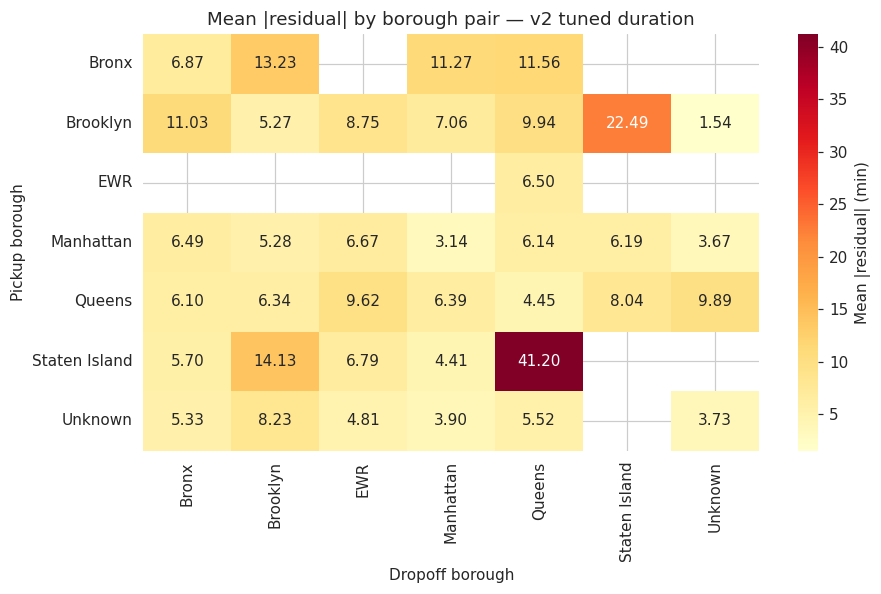

In [ ]:
heat = diag.pivot_table(index="pu", columns="do", values="abs_res", aggfunc="mean")

fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.heatmap(heat, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "Mean |residual| (min)"}, ax=ax)

ax.set_xlabel("Dropoff borough")
ax.set_ylabel("Pickup borough")
ax.set_title("Mean |residual| by borough pair — v2 tuned duration")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "v2_residual_borough_heatmap.png")

plt.show()

## 20. Full-Dataset Run *(gated — set `USE_FULL_DATASET = True` to enable)*

Retrain on the entire cleaned parquet with `xgb.QuantileDMatrix` so the histogram bins are built from a quantile sketch rather than a dense matrix.

In [ ]:
if USE_FULL_DATASET:

    print(f"Training on full cleaned parquet: {len(df_clean):,} rows")

    X_full = df_clean[ALL_FEATURES]
    y_full = df_clean[TARGET]

    X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.1, random_state=SEED)

    dtrain = xgb.QuantileDMatrix(X_tr, label=y_tr, enable_categorical=True)
    dtest  = xgb.QuantileDMatrix(X_te, label=y_te, enable_categorical=True, ref=dtrain)

    booster_full = xgb.train(
        params={k: v for k, v in final_params.items() if k != "n_estimators"},
        dtrain=dtrain,
        num_boost_round=final_params["n_estimators"],
        evals=[(dtest, "test")],
        early_stopping_rounds=50,
        verbose_eval=100,
    )

    pred_full = booster_full.predict(dtest)
    rmse_full = float(np.sqrt(mean_squared_error(y_te, pred_full)))
    mae_full = float(mean_absolute_error(y_te, pred_full))
    r2_full = float(r2_score(y_te, pred_full))

    print(f"\nFull-dataset — RMSE: {rmse_full:.3f} min | MAE: {mae_full:.3f} min | R²: {r2_full:.4f}")

    # Overwrite xgb_v2_duration.json with the full-data booster

    booster_full.save_model(str(OUTPUT_DIR / "xgb_v2_duration.json"))

    print(f"✓ Overwrote {OUTPUT_DIR / 'xgb_v2_duration.json'} with full-data booster.")

else:
    print("Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.")
    
    rmse_full = mae_full = r2_full = None

Full-dataset run skipped. Flip USE_FULL_DATASET=True in Section 2 to enable.


## Summary

In [ ]:
summary = {
    "v2_tuned_holdout":  {"rmse": rmse_v2, "mae": mae_v2, "r2": r2_v2},
    "v2_tuned_kfold": {
        "k": CV_FOLDS,
        "rmse_mean": float(cv_summary.loc["mean", "rmse"]),
        "rmse_std":  float(cv_summary.loc["std",  "rmse"]),
        "mae_mean":  float(cv_summary.loc["mean", "mae"]),
        "mae_std":   float(cv_summary.loc["std",  "mae"]),
        "r2_mean":   float(cv_summary.loc["mean", "r2"]),
        "r2_std":    float(cv_summary.loc["std",  "r2"]),
    },
    "v2_tuned_full":  ({"rmse": rmse_full, "mae": mae_full, "r2": r2_full}
                       if USE_FULL_DATASET else None),
    "best_params":    study.best_params,
    "n_trials":       N_TRIALS,
    "sample_size":    SAMPLE_SIZE,
    "tuning_sample":  TUNING_SAMPLE,
    "features":       ALL_FEATURES,
    "duration_bounds":[DUR_MIN, DUR_MAX],
    "dist_bounds":    [DIST_MIN, DIST_MAX],
    "seed":           SEED,
    "model_artifact": "xgb_v2_duration.json",
}

with open(METRICS_DIR / "v2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 64)
print(" v2 TUNED DURATION MODEL — DECK SUMMARY")
print("=" * 64)
print(f"  v2 tuned (held-out)   : RMSE {rmse_v2:.2f} min  | MAE {mae_v2:.2f} min  | R² {r2_v2:.3f}")
print(f"  v2 tuned ({CV_FOLDS}-fold CV)  : RMSE {cv_summary.loc['mean','rmse']:.2f} "
      f"± {cv_summary.loc['std','rmse']:.2f}  |  R² {cv_summary.loc['mean','r2']:.3f} "
      f"± {cv_summary.loc['std','r2']:.3f}")

if USE_FULL_DATASET:
    print(f"  v2 tuned (full data)  : RMSE {rmse_full:.2f} min | MAE {mae_full:.2f} min | R² {r2_full:.3f}")
    
print()
print(f"  Model artifact   : {OUTPUT_DIR / 'xgb_v2_duration.json'}")
print(f"  Figures saved to : {FIGURE_DIR}")
print(f"  Metrics saved to : {METRICS_DIR}")
print()
print(f"  Next step: copy xgb_v2_duration.json into the Streamlit MODEL_DIR")
print(f"  alongside xgb_v2_fare.json. Restart the demo and the Trip duration")
print(f"  metric tile will populate.")

 v2 TUNED DURATION MODEL — DECK SUMMARY
  v2 tuned (held-out)   : RMSE 5.41 min  | MAE 3.60 min  | R² 0.823
  v2 tuned (5-fold CV)  : RMSE 5.41 ± 0.01  |  R² 0.824 ± 0.001

  Model artifact   : /content/drive/MyDrive/DSCI 592/v2_tuned_duration/xgb_v2_duration.json
  Figures saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_duration/figures
  Metrics saved to : /content/drive/MyDrive/DSCI 592/v2_tuned_duration/metrics

  Next step: copy xgb_v2_duration.json into the Streamlit MODEL_DIR
  alongside xgb_v2_fare.json. Restart the demo and the Trip duration
  metric tile will populate.


## 22. Next Steps

- `tip_v2_tuned.ipynb` — binary classifier on `tipped`, full dataset (no payment-type filter, per discussion). Objective `binary:logistic`, calibration plot replaces residuals.
- `demand_v2_tuned.ipynb` — count regression on pickups per `(PU_borough, date, hour)`. Needs an aggregation cell up front to derive the target; the rest of the pipeline mirrors this one.

**Modeling refinements :**
- Promote `PU_borough`/`DO_borough` to full `PULocationID`/`DOLocationID` (263 zones) for finer spatial resolution. Native categorical handles the cardinality without OHE blowup.
- Try a quantile regression head (`reg:quantileerror` with `quantile_alpha=0.5`) to optimize for median absolute error instead of RMSE — duration distributions are right-skewed, so the median is arguably the more honest point estimate.
- Add a `pickup_hour × PU_borough` interaction feature explicitly (currently only learnable through tree splits).